In [1]:
import jax.numpy as jnp
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math

import sys
from absl import flags
from ml_collections.config_flags import config_flags

import tensorflow as tf
tf.config.experimental.set_visible_devices([], "GPU") # Отключение GPU для TensorFlow

import os
import jax
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.8'

from td_sa_stack import get_dataset, TrainerModuleSingle, RegressionInceptionNetV1

%load_ext autoreload
%autoreload 2

2025-06-14 13:05:37.633446: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749906337.653251   17789 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749906337.659671   17789 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749906337.675232   17789 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749906337.675246   17789 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1749906337.675248   17789 computation_placer.cc:177] computation placer alr

In [2]:
sys.argv = [
    "",
    "--config=td_sa_stack/config.py",
]

config_flags.DEFINE_config_file("config", None, "Training configuration.", lock_config=True)
# flags.DEFINE_string("workdir", None, "Work directory.")
# flags.DEFINE_enum("mode", None, ["train", "eval", "fid_stats"], "Running mode: train, eval or fid_stats")
# flags.DEFINE_string("eval_folder", "eval", "The folder name for storing evaluation results")


FLAGS = flags.FLAGS
FLAGS(sys.argv)

config = FLAGS.config

2025-06-14 13:05:41.225803: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.



Итоговый JAX массив картинок: (5, 32, 32, 3)


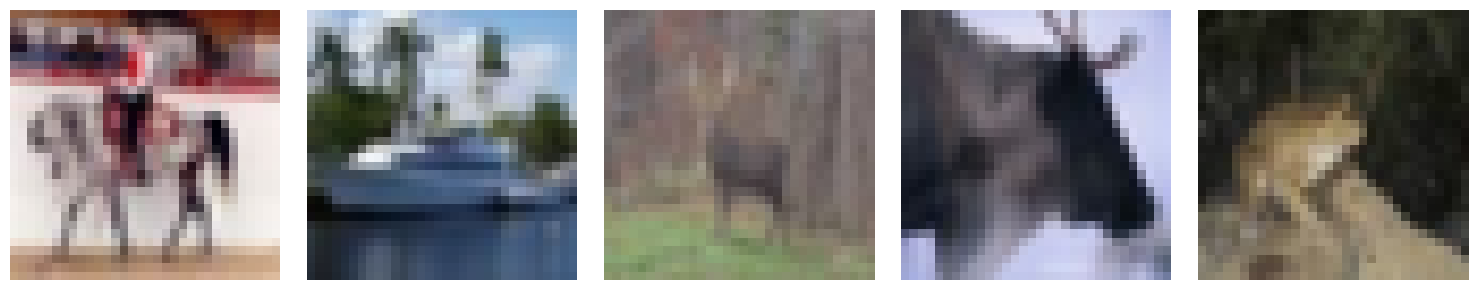


Тип данных: uint8
Диапазон значений: [0, 249]
Форма одной картинки: (32, 32, 3)
После нормализации: [0.000, 0.976]


In [3]:
dataset = tfds.load('cifar10', split='train', as_supervised=True, shuffle_files=False)

images = []
for i, (image, _) in enumerate(dataset.take(5)):
    image_numpy = image.numpy()
    image_jax = jnp.array(image_numpy)
    images.append(image_jax)

images_array = jnp.stack(images)

print(f"\nИтоговый JAX массив картинок: {images_array.shape}")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    image_to_show = np.array(images[i])
    axes[i].imshow(image_to_show)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"\nТип данных: {images_array.dtype}")
print(f"Диапазон значений: [{images_array.min()}, {images_array.max()}]")
print(f"Форма одной картинки: {images_array[0].shape}")

images_normalized = images_array / 255.0
print(f"После нормализации: [{images_normalized.min():.3f}, {images_normalized.max():.3f}]") 

In [4]:
config.train.batch_size = 20

train_ds, _, _ = get_dataset(config)

trainer = TrainerModuleSingle(config=config,
                              model_class=RegressionInceptionNetV1,
                              version=2)

Batch dimensions: [1, 20]
Initializing model with batch shape: (20, 32, 32, 6)


/workspace/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


Loaded model from step 10000


In [5]:
trainer.checkpoint_exists()

True

In [6]:
def get_trajectory(image: jnp.ndarray):
	min_num_steps, max_num_steps = config.data.min_traj_len, config.data.max_traj_len
	reward, gamma = config.data.reward_final, config.data.gamma

	def normalize(image):
		image /= 255.0
		image = (image-0.5) / 0.5
		return image

	image = normalize(image)

	steps_key, z_key = jax.random.split(jax.random.PRNGKey(config.seed))

	num_steps = jax.random.randint(steps_key,
								   shape=(),
								   minval=min_num_steps,
								   maxval=max_num_steps)
	z = jax.random.normal(z_key, image.shape, dtype=image.dtype)

	ts = math.sqrt(2) * jnp.arange(num_steps, dtype=jnp.float32) % 1.0 # Имитация равномерного распределения
	ts = jnp.sort(ts, descending=False) 
	ts = jnp.reshape(ts, (num_steps, 1, 1, 1))

	trajectory = z * (1 - ts) + image * ts # [None, 32, 32, 3] * [num_steps, None, None, None]

	s = trajectory[:-1]                # [num_steps-1, 32, 32, 3]
	s_next = trajectory[1:]            # [num_steps-1, 32, 32, 3]
	a = s_next - s                     # [num_steps-1, 32, 32, 3]
	a_next = image[None, ...] - s_next # [num_steps-1, 32, 32, 3]

	rewards = reward * (gamma ** jnp.arange(num_steps-1, 0, -1, dtype=jnp.float32)) # [num_steps-1]
	rewards = jnp.reshape(rewards, (-1, 1))

	transitions = jnp.concat([s, a, s_next, a_next], axis=-1) # [num_steps-1, 32, 32, 3*4=12]
	return transitions, rewards

In [7]:
trajectories = []
for image in images:
    transitions, rewards = get_trajectory(image)
    trajectories.append((transitions, rewards))
    break

transitions = jnp.concatenate([transition for transition, _ in trajectories])
rewards = jnp.concatenate([reward for _, reward in trajectories])

In [8]:
def get_q_values(transitions):
	return trainer.model.apply({"params": trainer.state.params, "batch_stats": trainer.state.batch_stats},
                        	 transitions,  # (70, 32, 32, 6)
                         	 train=False,
                         	 train_rng=None,
                         	 mutable=False)

print(f"Q-values shape: {get_q_values(transitions).shape}")

Q-values shape: (70, 1)


In [17]:
states, actions = transitions[..., :3], transitions[..., 3:6]

trajectory = jnp.concatenate([states, -actions], axis=-1)
reward = rewards[..., 0]

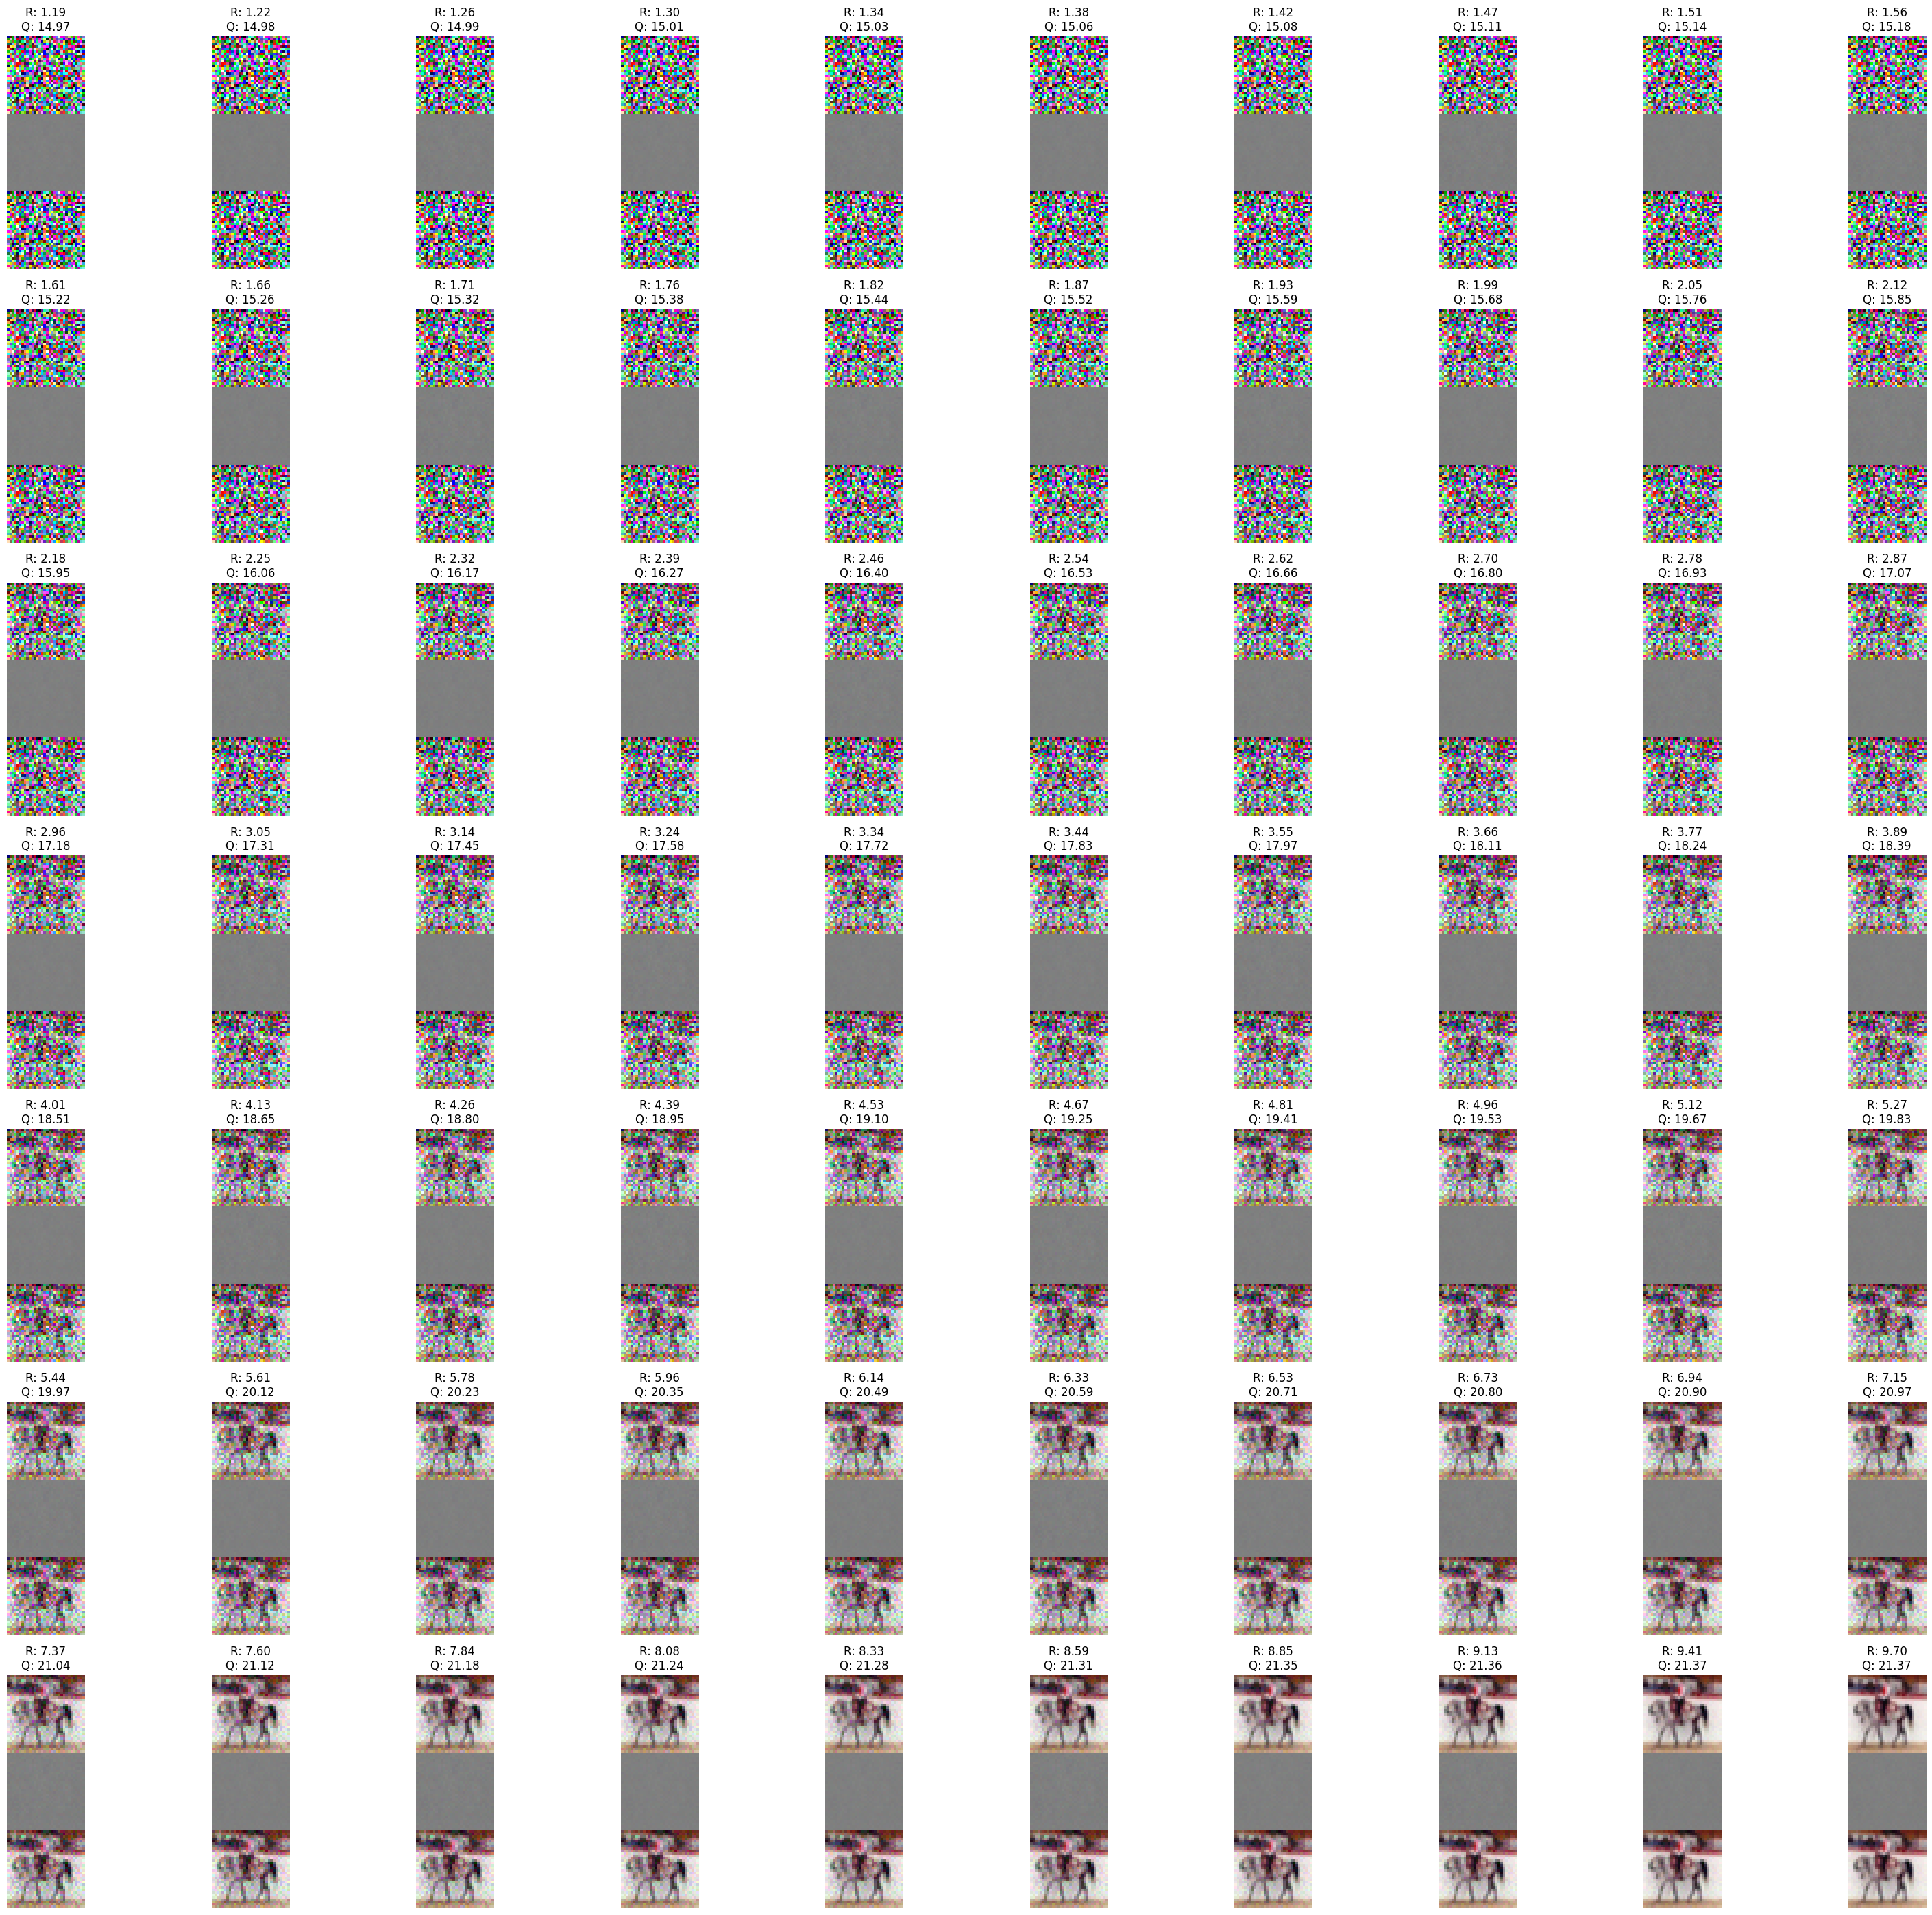

In [18]:
samples_count = 10
wide = 10

plt.figure(figsize=(30, 4 * samples_count))
gs = GridSpec(samples_count, wide)

# trajectory = transitions[..., :6]
# reward = rewards[..., 0]

params, batch_stats = trainer.state.params, trainer.state.batch_stats
q_vals = trainer.model.apply({"params": params, "batch_stats": batch_stats},
							 trajectory,
							 train=False)

for ind in range(len(q_vals)):
	i, j = ind // wide, ind % wide
	ax = plt.subplot(gs[i, j])
	s = trajectory[ind, :, :, :3] * 0.5 + 0.5
	a = trajectory[ind, :, :, 3:6] * 0.5 + 0.5
	s_next = (trajectory[ind, :, :, :3] + trajectory[ind, :, :, 3:6]) * 0.5 + 0.5
	ax.imshow(np.concatenate([s, a, s_next], axis=0))

	ax.axis('off')
	ax.set_title(f"R: {reward[ind]:.2f}\nQ: {q_vals[ind, 0]:.2f}")

plt.tight_layout()
plt.show()

In [20]:
states, actions = transitions[..., :3], transitions[..., 3:6]

trajectory = jnp.concatenate([states, actions], axis=-1)
reward = rewards[..., 0]

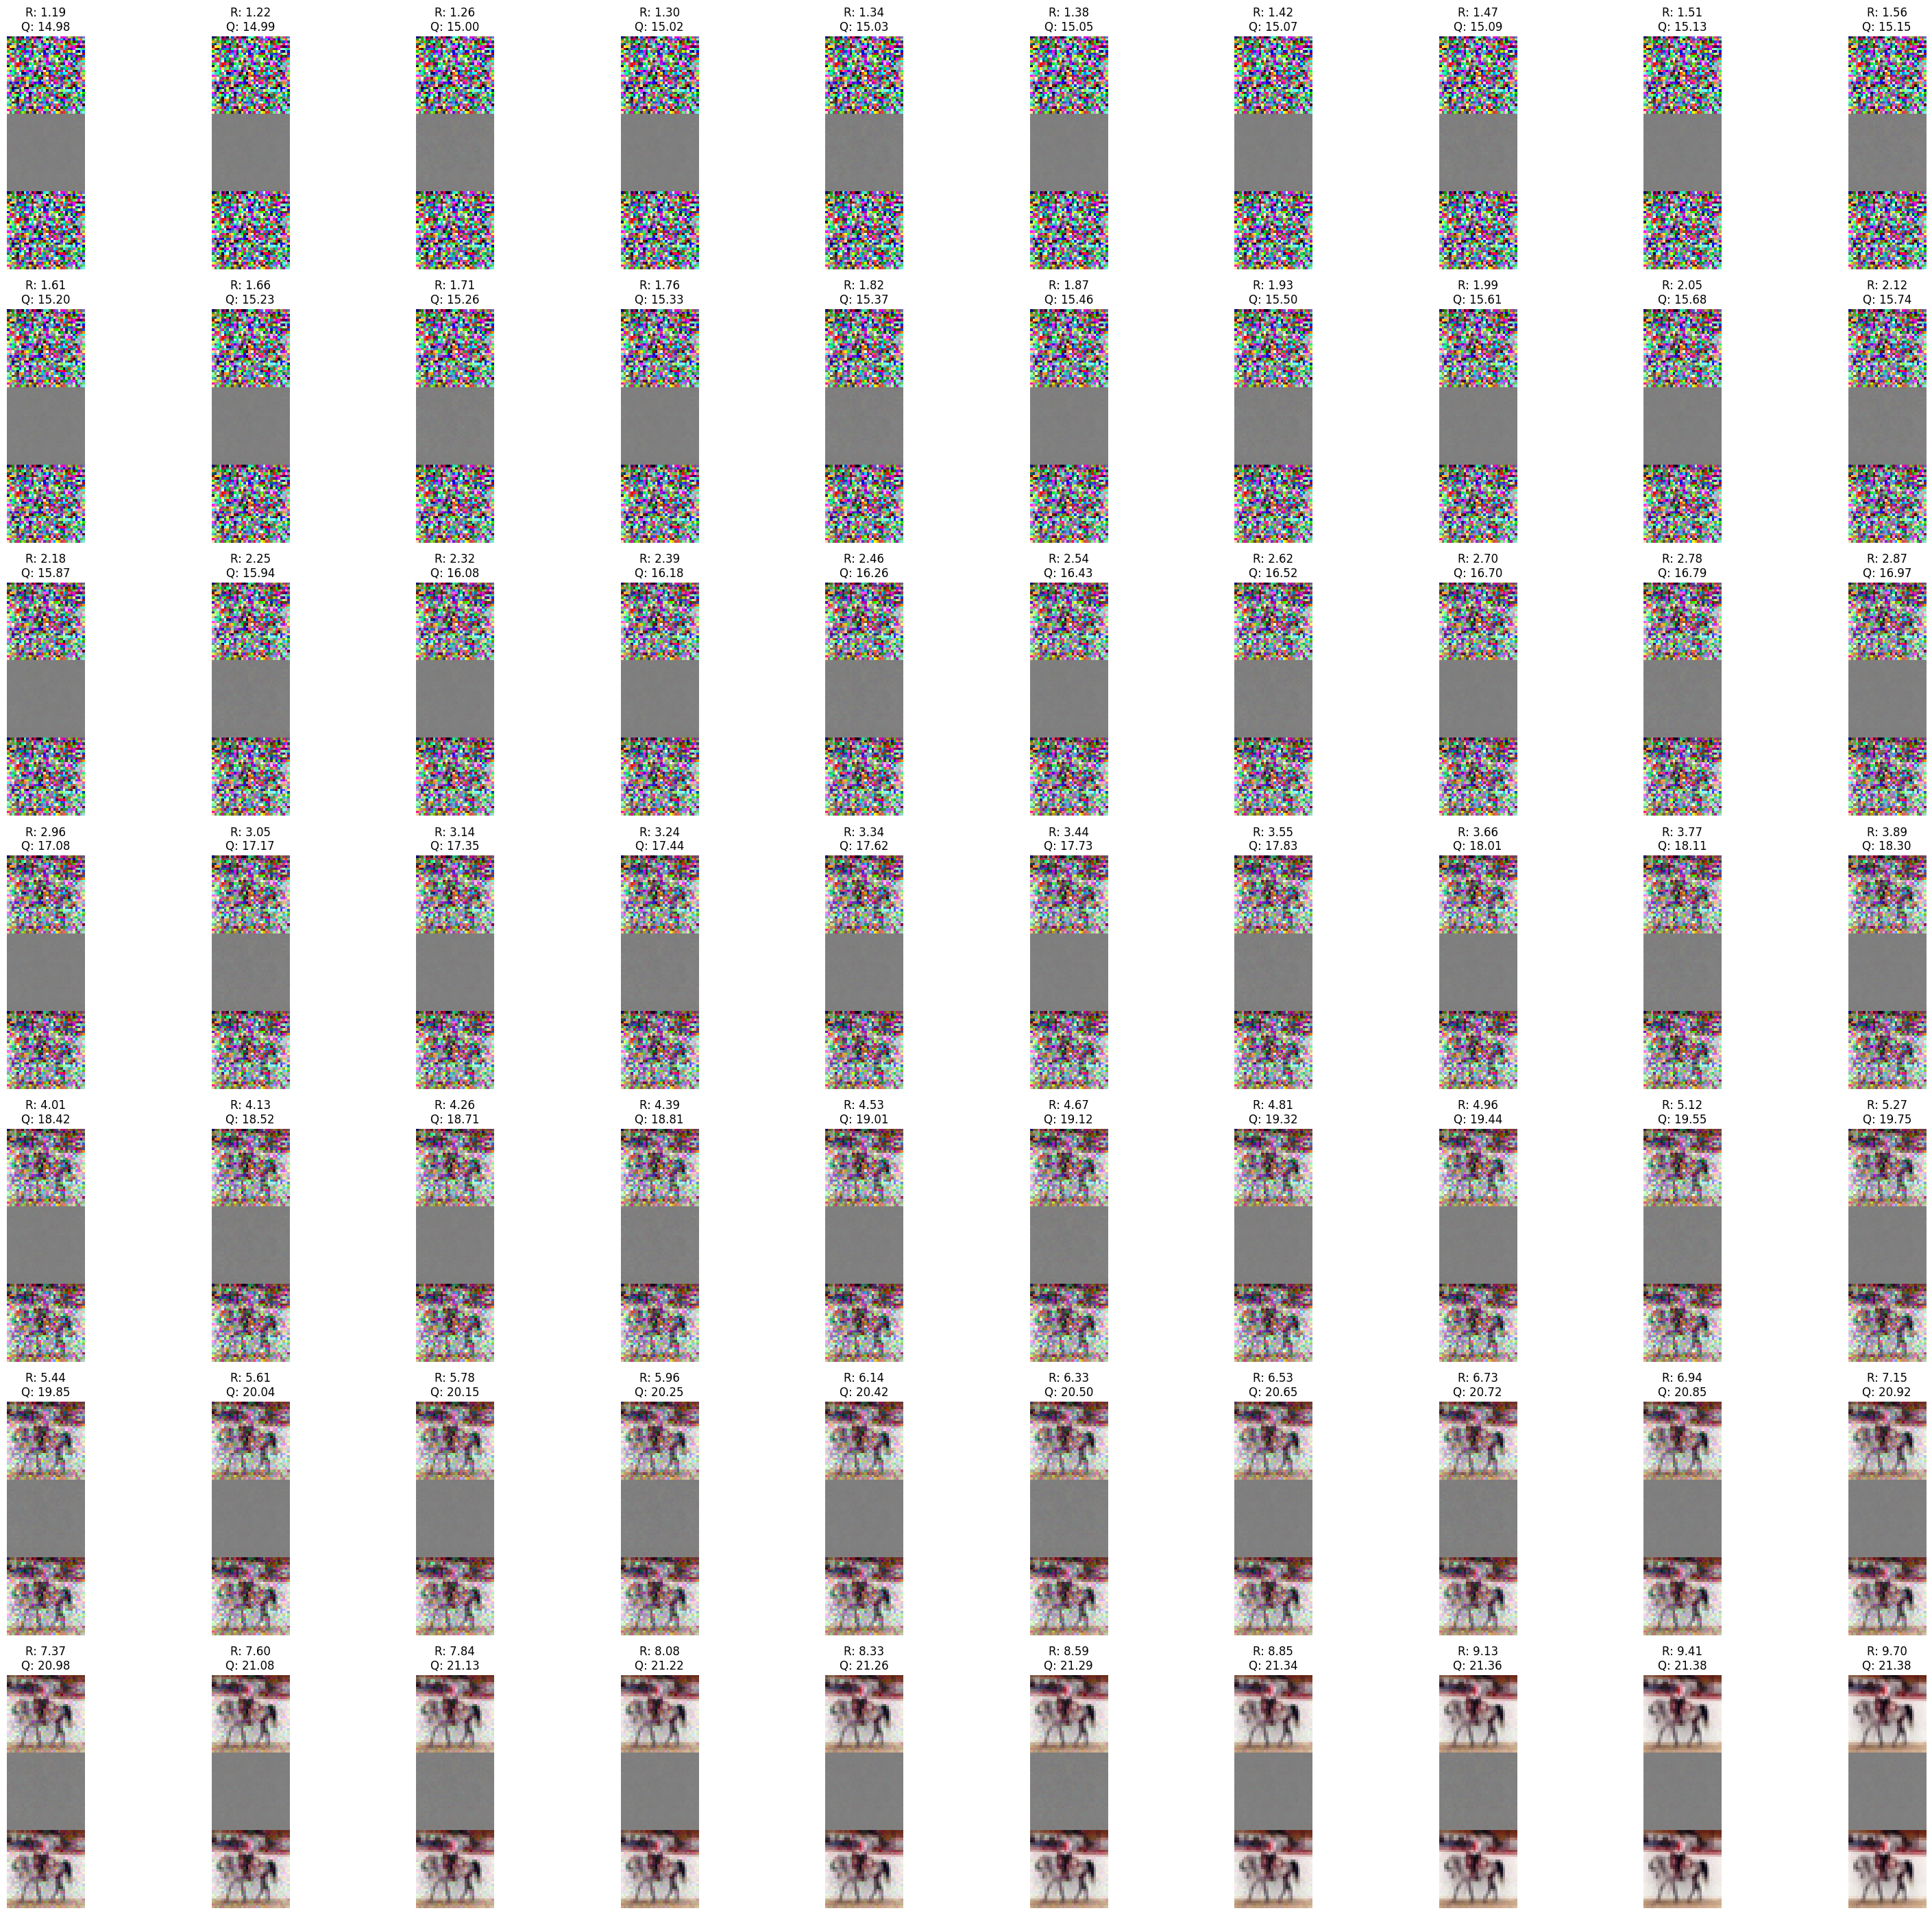

In [21]:
samples_count = 10
wide = 10

plt.figure(figsize=(30, 4 * samples_count))
gs = GridSpec(samples_count, wide)

# trajectory = transitions[..., :6]
# reward = rewards[..., 0]

params, batch_stats = trainer.state.params, trainer.state.batch_stats
q_vals = trainer.model.apply({"params": params, "batch_stats": batch_stats},
							 trajectory,
							 train=False)

for ind in range(len(q_vals)):
	i, j = ind // wide, ind % wide
	ax = plt.subplot(gs[i, j])
	s = trajectory[ind, :, :, :3] * 0.5 + 0.5
	a = trajectory[ind, :, :, 3:6] * 0.5 + 0.5
	s_next = (trajectory[ind, :, :, :3] + trajectory[ind, :, :, 3:6]) * 0.5 + 0.5
	ax.imshow(np.concatenate([s, a, s_next], axis=0))

	ax.axis('off')
	ax.set_title(f"R: {reward[ind]:.2f}\nQ: {q_vals[ind, 0]:.2f}")

plt.tight_layout()
plt.show()